Original dataset shape: (992, 25)
✅ Regression MSE: 1.9321, R²: 0.5224
✅ Classification Acc: 0.722, Prec: 0.750, Rec: 0.250, F1: 0.375, ROC-AUC: 0.714


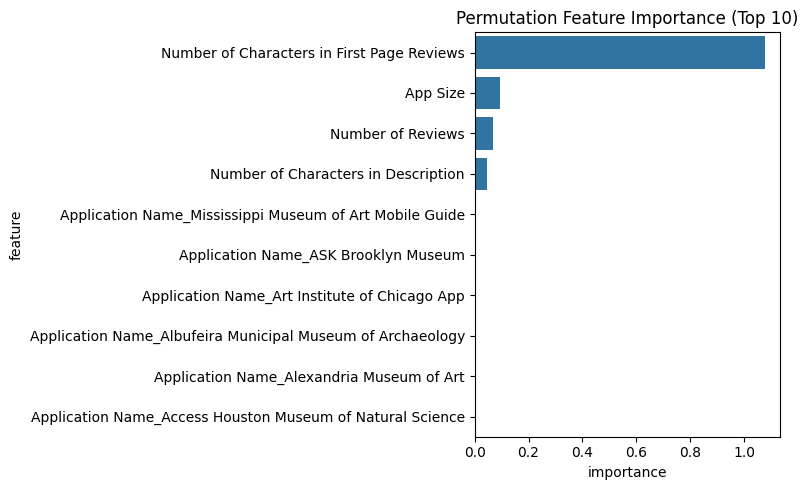

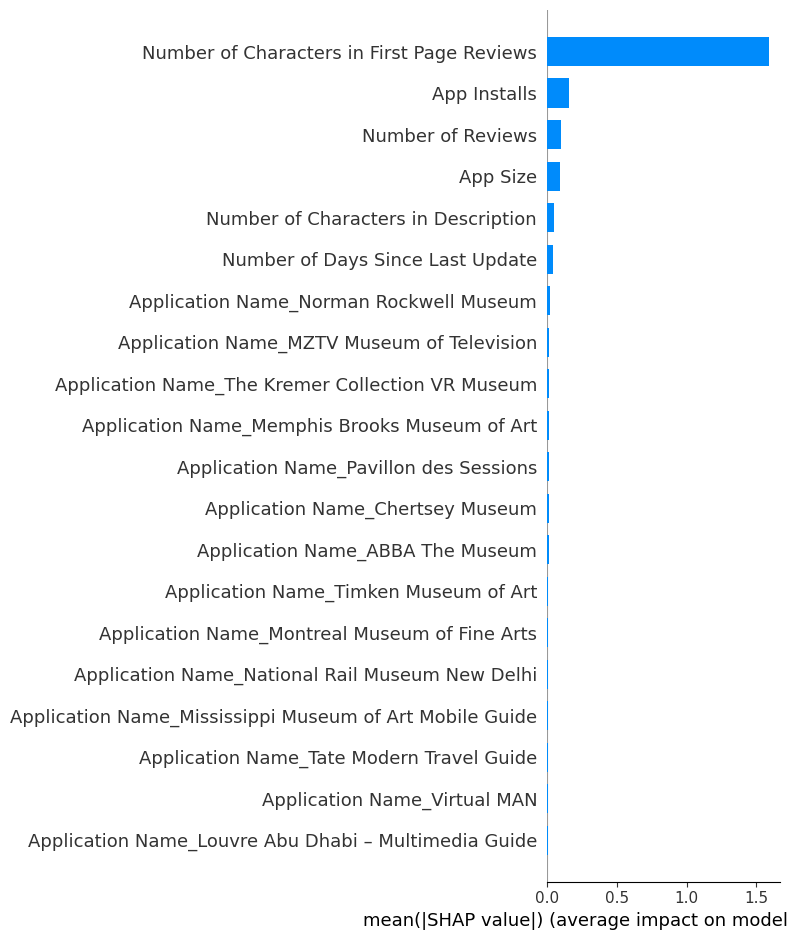

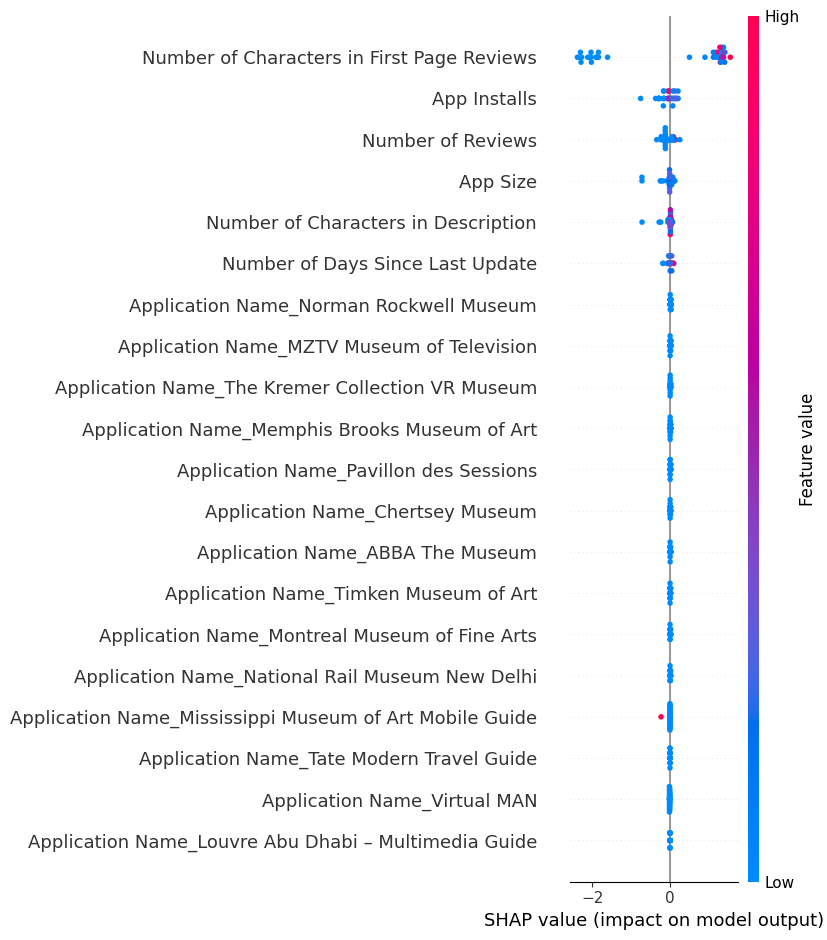

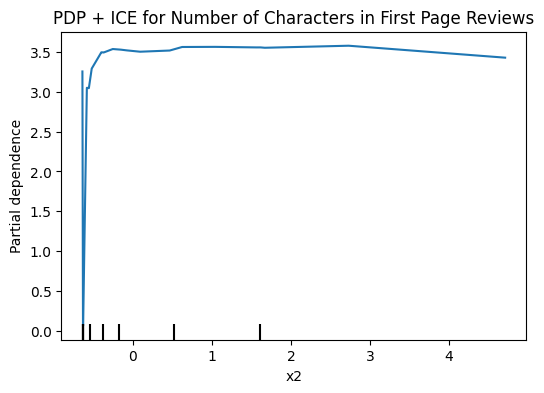

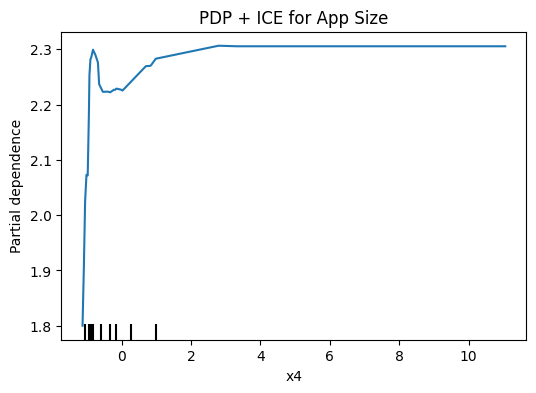

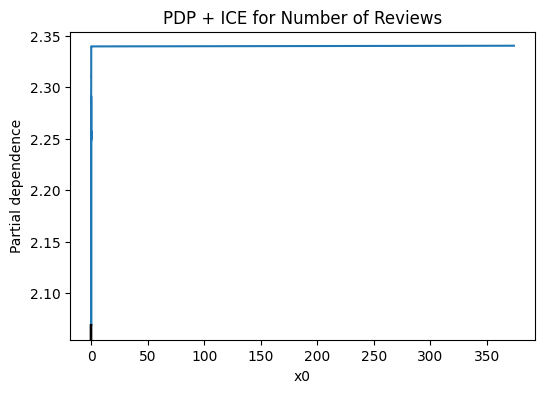

In [ ]:
# ============================ #
# INSTALL REQUIRED LIBRARIES
# ============================ #
!pip install catboost xgboost lightgbm shap lime seaborn --quiet

# ============================ #
# IMPORT LIBRARIES
# ============================ #
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
from lime.lime_tabular import LimeTabularExplainer
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 1️⃣ LOAD DATASET
# ============================================================
df = pd.read_csv("/content/Cultural Heritage Apps Dataset.csv")
print("Original dataset shape:", df.shape)

# Keep meaningful columns only
df = df.loc[:, df.notna().any(axis=0)]
df = df.dropna(subset=["Overall Rate"]).reset_index(drop=True)

# ============================================================
# 2️⃣ TARGETS
# ============================================================
# Regression target
target_reg = "Overall Rate"

# Classification target (High Rated = 1 if rating ≥ 4)
df["High_Rated"] = (df["Overall Rate"] >= 4.0).astype(int)
target_clf = "High_Rated"

# ============================================================
# 3️⃣ FEATURE SELECTION
# ============================================================
# Pick a subset of features that are numeric or relevant text-based
numeric_features = [
    "Number of Reviews",
    "Number of Characters in Description",
    "Number of Characters in First Page Reviews",
    "Number of Days Since Last Update",
    "App Size",
    "App Installs"
]

categorical_features = ["Application Name"]

# ============================================================
# 4️⃣ PREPROCESSING
# ============================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
], remainder='passthrough') # Added remainder='passthrough'

# ============================================================
# 5️⃣ TRAIN-TEST SPLIT
# ============================================================
X = df[numeric_features + categorical_features]
y_reg = df[target_reg]
y_clf = df[target_clf]

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# ============================================================
# 6️⃣ RANDOM FOREST REGRESSOR
# ============================================================
reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])
reg_model.fit(X_train, y_train_reg)
y_pred_reg = reg_model.predict(X_test)

mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"✅ Regression MSE: {mse:.4f}, R²: {r2:.4f}")

# ============================================================
# 7️⃣ RANDOM FOREST CLASSIFIER
# ============================================================
clf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])
clf_model.fit(X_train, y_train_clf)
y_pred_clf = clf_model.predict(X_test)
y_proba = clf_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf)
rec = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)
roc = roc_auc_score(y_test_clf, y_proba)
print(f"✅ Classification Acc: {acc:.3f}, Prec: {prec:.3f}, Rec: {rec:.3f}, F1: {f1:.3f}, ROC-AUC: {roc:.3f}")

# ============================================================
# 8️⃣ PERMUTATION IMPORTANCE
# ============================================================
processed_X_test = preprocessor.transform(X_test).toarray() # Convert to dense array
feature_names = numeric_features + list(preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features))

perm_res = permutation_importance(
    reg_model.named_steps["model"],
    processed_X_test,
    y_test_reg,
    n_repeats=10,
    random_state=42
)
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm_res.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_df.head(10), x="importance", y="feature")
plt.title("Permutation Feature Importance (Top 10)")
plt.tight_layout()
plt.show()

# ============================================================
# 9️⃣ SHAP EXPLAINABILITY (GLOBAL)
# ============================================================
explainer = shap.TreeExplainer(reg_model.named_steps["model"])
shap_values = explainer.shap_values(processed_X_test) # Use dense array

shap.summary_plot(shap_values, processed_X_test, feature_names=feature_names, plot_type="bar")
shap.summary_plot(shap_values, processed_X_test, feature_names=feature_names)

# ============================================================
# 🔟 LIME EXPLAINABILITY (LOCAL)
# ============================================================
X_train_trans = preprocessor.fit_transform(X_train).toarray() # Convert to dense array
X_test_trans = preprocessor.transform(X_test).toarray() # Convert to dense array

lime_explainer = LimeTabularExplainer(
    training_data=X_train_trans,
    feature_names=feature_names,
    mode="regression"
)
i = np.random.randint(0, len(X_test_trans))
exp = lime_explainer.explain_instance(X_test_trans[i], reg_model.named_steps["model"].predict, num_features=10)
exp.show_in_notebook(show_table=True)

# ============================================================
# 11️⃣ PDP + ICE PLOTS
# ============================================================
top_feats = imp_df["feature"].head(3).tolist()
for feat in top_feats:
    fig, ax = plt.subplots(figsize=(6, 4))
    PartialDependenceDisplay.from_estimator(reg_model.named_steps["model"], processed_X_test, [feature_names.index(feat)], ax=ax) # Use dense array
    plt.title(f"PDP + ICE for {feat}")
    plt.show()



In [ ]:
# ============================================================
# CULTURAL HERITAGE APPS - EXTENDED XAI PIPELINE (ALL MODELS)
# ============================================================
# Save this as `xai_cultural_apps_full.py` or paste into a Jupyter/Colab cell.
# Make sure 'Cultural Heritage Apps Dataset.csv' is uploaded to the runtime.
# ============================================================

import os, sys, warnings, math
warnings.filterwarnings("ignore")
os.makedirs("output", exist_ok=True)

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, mean_squared_error, r2_score, roc_curve, auc)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, AdaBoostClassifier, AdaBoostRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Optional packages (XGBoost, LightGBM, CatBoost, SHAP, LIME, TensorFlow)
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False

try:
    from catboost import CatBoostClassifier, CatBoostRegressor
    CAT_AVAILABLE = True
except Exception:
    CAT_AVAILABLE = False

# Try to import shap/lime/tf; if missing, code will skip
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
except Exception:
    LIME_AVAILABLE = False

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks
    TF_AVAILABLE = True
except Exception:
    TF_AVAILABLE = False

# -------------------------
# USER: set path to your CSV file
DATA_PATH = "Cultural Heritage Apps Dataset.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Upload CSV to the runtime or set DATA_PATH accordingly.")

# -------------------------
# 0. Load data and quick cleanup
df = pd.read_csv(DATA_PATH)
print("Loaded dataset shape:", df.shape)

# drop fully-empty columns
df = df.loc[:, df.notna().any(axis=0)].copy()
print("After dropping empty cols:", df.shape)

# Ensure the primary target column exists
if "Overall Rate" not in df.columns:
    raise ValueError("The dataset must contain an 'Overall Rate' column.")

# Drop rows with no Overall Rate
df = df.dropna(subset=["Overall Rate"]).reset_index(drop=True)
df["Overall Rate"] = pd.to_numeric(df["Overall Rate"], errors="coerce")
df = df.dropna(subset=["Overall Rate"]).reset_index(drop=True)
print("Rows with Overall Rate present:", df.shape[0])

# Create classification target
df["High_Rated"] = (df["Overall Rate"] >= 4.0).astype(int)

# -------------------------
# 1. Candidate feature lists (detect which exist)
candidate_numeric = [
    "Number of Reviews",
    "Number of Characters in Description",
    "Number of Characters in First Page Reviews",
    "Number of Days Since Last Update",
    "App Size",         # might not exist
    "App Installs"      # might not exist
]

candidate_categorical = [
    "Application Name",
    "Application Description",   # large-cardinality textual field - used carefully
    "Last Update",
    "First Page Reviews"
]

# Build final feature lists by checking existence
numeric_features = [c for c in candidate_numeric if c in df.columns and df[c].dtype != object]
categorical_features = [c for c in candidate_categorical if c in df.columns]

# If there are too few numeric features, try to coerce numeric-like columns
if len(numeric_features) < 2:
    # find other numeric-looking columns
    for c in df.columns:
        if c not in numeric_features + categorical_features + ["Overall Rate","High_Rated"]:
            try:
                s = pd.to_numeric(df[c], errors='coerce')
                if s.notnull().sum() / len(s) > 0.6:  # reasonably numeric
                    numeric_features.append(c)
                if len(numeric_features) >= 4:
                    break
            except:
                pass

print("Numeric features used:", numeric_features)
print("Categorical features used (small set):", categorical_features[:3])

# For high-cardinality textual fields, we will drop or use length-simplifications
# Create derived features (lengths) if textual description columns exist
if "Application Description" in df.columns:
    df["desc_len"] = df["Application Description"].astype(str).apply(len)
    if "desc_len" not in numeric_features:
        numeric_features.append("desc_len")
if "First Page Reviews" in df.columns:
    df["first_review_len"] = df["First Page Reviews"].astype(str).apply(len)
    if "first_review_len" not in numeric_features:
        numeric_features.append("first_review_len")

# limit categorical features to small-cardinality ones
cat_small = []
for c in categorical_features:
    nunique = df[c].nunique()
    if 1 < nunique <= 30:
        cat_small.append(c)
    else:
        # ignore very high-cardinality categories (we can encode separately if needed)
        pass
categorical_features = cat_small
print("Categorical features (kept):", categorical_features)

# Final features
FEATURES = numeric_features + categorical_features
if len(FEATURES) == 0:
    raise ValueError("No usable features detected automatically. Please provide features manually.")

# Prepare X and targets
X = df[FEATURES].copy()
y_reg = df["Overall Rate"].copy()
y_clf = df["High_Rated"].copy()

# -------------------------
# 2. Preprocessing pipelines
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", num_transformer, numeric_features),
    ("cat", cat_transformer, categorical_features)
], remainder="drop")

# Fit-transform once to get transformed shapes and feature names
preprocessor.fit(X)
X_proc = preprocessor.transform(X)  # full transformed matrix (numpy)

# Build feature names
feature_names = []
feature_names += numeric_features
if len(categorical_features) > 0:
    try:
        ohe_names = list(preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features))
    except Exception:
        ohe_names = []
    feature_names += ohe_names

# ---------------
# 3. Train-test split (classification and regression; keep same X split)
X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.20, random_state=42, stratify=y_clf
)

# Transform train/test
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# -------------------------
# 4. Model definitions
classification_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "GaussianNB": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42)
}
if XGB_AVAILABLE:
    classification_models["XGBoost"] = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
if LGBM_AVAILABLE:
    classification_models["LightGBM"] = LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
if CAT_AVAILABLE:
    classification_models["CatBoost"] = CatBoostClassifier(iterations=200, verbose=0, random_seed=42)

regression_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "KNNRegressor": KNeighborsRegressor()
}
if XGB_AVAILABLE:
    regression_models["XGBoostRegressor"] = xgb.XGBRegressor(random_state=42)
if LGBM_AVAILABLE:
    regression_models["LightGBMRegressor"] = LGBMRegressor(random_state=42)
if CAT_AVAILABLE:
    regression_models["CatBoostRegressor"] = CatBoostRegressor(iterations=200, verbose=0, random_seed=42)

# -------------------------
# 5. Train & evaluate classification models
clf_results = []
for name, model in classification_models.items():
    try:
        print(f"Training classifier: {name}")
        model.fit(X_train_proc, y_train_clf)
        y_pred = model.predict(X_test_proc)
        try:
            y_prob = model.predict_proba(X_test_proc)[:, 1]
        except Exception:
            # decision function fallback
            try:
                dfcn = model.decision_function(X_test_proc)
                y_prob = (dfcn - dfcn.min())/(dfcn.max()-dfcn.min()+1e-9)
            except Exception:
                y_prob = None
        acc = accuracy_score(y_test_clf, y_pred)
        prec = precision_score(y_test_clf, y_pred, zero_division=0)
        rec = recall_score(y_test_clf, y_pred, zero_division=0)
        f1 = f1_score(y_test_clf, y_pred, zero_division=0)
        roc = roc_auc_score(y_test_clf, y_prob) if y_prob is not None else math.nan
        clf_results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC_AUC": roc})
        # save confusion matrix figure
        cm = confusion_matrix(y_test_clf, y_pred)
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{name} Confusion Matrix")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.tight_layout()
        plt.savefig(f"output/{name}_confusion_matrix.png")
        plt.close()
    except Exception as e:
        print(f"Failed {name}: {e}")

clf_df = pd.DataFrame(clf_results).sort_values("Accuracy", ascending=False)
clf_df.to_csv("output/classification_results_summary.csv", index=False)

# Plot classification accuracy comparison
plt.figure(figsize=(8,4))
plt.bar(clf_df["Model"], clf_df["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.title("Classification Accuracy Comparison")
plt.tight_layout()
plt.savefig("output/classification_accuracy_comparison.png")
plt.close()

# ROC curves combined
plt.figure(figsize=(8,6))
for row in clf_results:
    name = row["Model"]
    try:
        model = classification_models[name]
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test_proc)[:,1]
            fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
    except Exception:
        pass
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Classifiers)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("output/roc_curves_classifiers.png")
plt.close()

# -------------------------
# 6. Train & evaluate regression models
reg_results = []
for name, model in regression_models.items():
    try:
        print(f"Training regressor: {name}")
        model.fit(X_train_proc, y_train_reg)
        y_pred = model.predict(X_test_proc)
        mse = mean_squared_error(y_test_reg, y_pred)
        rmse = math.sqrt(mse)
        r2 = r2_score(y_test_reg, y_pred)
        reg_results.append({"Model": name, "RMSE": rmse, "MSE": mse, "R2": r2})
    except Exception as e:
        print(f"Failed {name}: {e}")

reg_df = pd.DataFrame(reg_results).sort_values("R2", ascending=False)
reg_df.to_csv("output/regression_results_summary.csv", index=False)

# Plot regression R2 comparison
plt.figure(figsize=(8,4))
plt.bar(reg_df["Model"], reg_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.title("Regression R² Comparison")
plt.tight_layout()
plt.savefig("output/regression_r2_comparison.png")
plt.close()

# -------------------------
# 7. Permutation importance (on best regressor if exists)
if len(reg_results) > 0:
    best_reg_name = reg_df.iloc[0]["Model"]
    print("Best regressor:", best_reg_name)
    best_reg = regression_models[best_reg_name]
    try:
        perm = permutation_importance(best_reg, X_test_proc, y_test_reg, n_repeats=10, random_state=42)
        imp_idx = np.argsort(perm.importances_mean)[::-1]
        feat_imp = pd.DataFrame({
            "feature": np.array(feature_names)[imp_idx],
            "importance_mean": perm.importances_mean[imp_idx],
            "importance_std": perm.importances_std[imp_idx]
        })
        feat_imp.to_csv("output/regressor_permutation_importance.csv", index=False)
        plt.figure(figsize=(8,5))
        sns.barplot(data=feat_imp.head(15), x="importance_mean", y="feature")
        plt.title(f"Permutation Importance - {best_reg_name} (Top 15)")
        plt.tight_layout()
        plt.savefig("output/permutation_importance_top15.png")
        plt.close()
    except Exception as e:
        print("Permutation importance failed:", e)

# -------------------------
# 8. SHAP explanations (global) if available and best tree model exists
if SHAP_AVAILABLE and len(reg_results) > 0:
    # prefer tree ensemble model
    tree_models = ["RandomForestRegressor", "XGBoostRegressor", "LightGBMRegressor", "CatBoostRegressor", "GradientBoostingRegressor"]
    chosen_model = None
    for nm in tree_models:
        if nm in regression_models:
            chosen_model = regression_models[nm]
            if chosen_model is not None:
                break
    if chosen_model is None:
        # fallback to best trained regressor earlier
        chosen_model = regression_models.get(best_reg_name, None)
    if chosen_model is not None:
        try:
            print("Running SHAP on model:", type(chosen_model).__name__)
            # For SHAP TreeExplainer, we may pass model directly
            explainer = shap.Explainer(chosen_model, X_train_proc)
            shap_values = explainer(X_test_proc)
            # summary plot (bar)
            shap.summary_plot(shap_values, features=X_test_proc, feature_names=feature_names, show=False)
            plt.tight_layout(); plt.savefig("output/shap_summary_bar.png"); plt.close()
            shap.summary_plot(shap_values, features=X_test_proc, feature_names=feature_names, show=False)
            plt.tight_layout(); plt.savefig("output/shap_summary_dot.png"); plt.close()
        except Exception as e:
            print("SHAP failed:", e)
else:
    print("SHAP not available or no regressors trained - skipping SHAP.")

# -------------------------
# 9. LIME local explanations (if available) - use best regressor/classifier
if LIME_AVAILABLE:
    try:
        from sklearn.utils import check_array
        # Use regressor explain_instance (regression)
        lime_explainer = LimeTabularExplainer(X_train_proc, feature_names=feature_names, mode="regression")
        idx = np.random.randint(0, X_test_proc.shape[0])
        top_regressor = regression_models[list(regression_models.keys())[0]]
        # prefer best_reg if available
        if best_reg_name in regression_models:
            top_regressor = regression_models[best_reg_name]
        exp = lime_explainer.explain_instance(X_test_proc[idx], top_regressor.predict, num_features=10)
        html_path = f"output/lime_regression_example_{idx}.html"
        exp.save_to_file(html_path)
        print("Saved LIME reg explanation to:", html_path)
    except Exception as e:
        print("LIME reg failed:", e)
else:
    print("LIME not available - skipping LIME.")

# -------------------------
# 10. Partial Dependence for top features (regressor)
try:
    top_features = feature_names[:3]  # first 3 features as example
    for feat in top_features:
        if feat in feature_names:
            feat_idx = feature_names.index(feat)
            fig, ax = plt.subplots(figsize=(6,4))
            # PartialDependenceDisplay expects an estimator and original X (2D array)
            PartialDependenceDisplay.from_estimator(best_reg, X_test_proc, [feat_idx], ax=ax)
            plt.title(f"PDP + ICE for {feat}")
            plt.tight_layout()
            plt.savefig(f"output/pdp_ice_{feat}.png")
            plt.close()
except Exception as e:
    print("PDP/ICE plotting failed:", e)

# -------------------------
# 11. Simple MLP (classification) if TF available
if TF_AVAILABLE:
    try:
        print("Training simple MLP classifier (TF)...")
        tf.random.set_seed(42)
        X_tr = X_train_proc.astype("float32")
        X_te = X_test_proc.astype("float32")
        y_tr = y_train_clf.values.astype("float32")
        y_te = y_test_clf.values.astype("float32")

        import tensorflow as tf
        from tensorflow.keras import layers, models, callbacks

        def build_mlp(input_dim):
            inp = layers.Input(shape=(input_dim,))
            x = layers.Dense(128, activation="relu")(inp)
            x = layers.Dropout(0.2)(x)
            x = layers.Dense(64, activation="relu")(x)
            out = layers.Dense(1, activation="sigmoid")(x)
            model = models.Model(inputs=inp, outputs=out)
            model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
            return model

        mlp = build_mlp(X_tr.shape[1])
        es = callbacks.EarlyStopping(patience=8, restore_best_weights=True)
        mlp.fit(X_tr, y_tr, validation_split=0.1, epochs=50, batch_size=32, callbacks=[es], verbose=0)
        y_proba_mlp = mlp.predict(X_te).ravel()
        y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)
        res_mlp = {
            "Model": "MLP_TF",
            "Accuracy": accuracy_score(y_te, y_pred_mlp),
            "Precision": precision_score(y_te, y_pred_mlp, zero_division=0),
            "Recall": recall_score(y_te, y_pred_mlp, zero_division=0),
            "F1": f1_score(y_te, y_pred_mlp, zero_division=0),
            "ROC_AUC": roc_auc_score(y_te, y_proba_mlp)
        }
        # append result and save confusion matrix
        clf_df = pd.concat([clf_df, pd.DataFrame([res_mlp])], ignore_index=True)
        plt.figure(figsize=(4,3))
        cm = confusion_matrix(y_te, y_pred_mlp)
        sns.heatmap(cm, annot=True, fmt="d")
        plt.title("MLP Confusion Matrix")
        plt.tight_layout()
        plt.savefig("output/MLP_confusion_matrix.png"); plt.close()
    except Exception as e:
        print("MLP training failed:", e)

# -------------------------
# 12. Save summary CSVs and print top results
clf_df.to_csv("output/classification_results_summary_final.csv", index=False)
reg_df.to_csv("output/regression_results_summary_final.csv", index=False)

print("\nSaved output files to ./output. Listing key files:")
for f in sorted(os.listdir("output")):
    print(" -", f)

print("\nTop classification results:")
print(clf_df.sort_values("Accuracy", ascending=False).head().to_string(index=False))

print("\nTop regression results:")
print(reg_df.sort_values("R2", ascending=False).head().to_string(index=False))

# End of script


Loaded dataset shape: (992, 25)
After dropping empty cols: (992, 14)
Rows with Overall Rate present: 177
Numeric features used: ['Number of Reviews', 'Number of Characters in Description', 'Number of Characters in First Page Reviews', 'Number of Days Since Last Update', 'App Size', 'App Installs']
Categorical features used (small set): ['Application Name', 'Application Description', 'Last Update']
Categorical features (kept): []
Training classifier: LogisticRegression
Training classifier: DecisionTree
Training classifier: RandomForest
Training classifier: AdaBoost
Training classifier: GradientBoosting
Training classifier: KNN
Training classifier: GaussianNB
Training classifier: SVM
Training classifier: XGBoost
Training classifier: LightGBM
Training classifier: CatBoost
Training regressor: LinearRegression
Training regressor: Ridge
Training regressor: Lasso
Training regressor: DecisionTreeRegressor
Training regressor: RandomForestRegressor
Training regressor: GradientBoostingRegressor
T

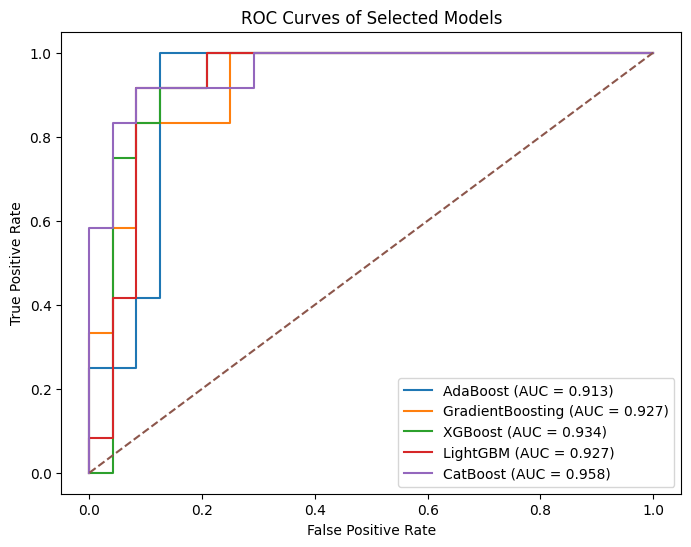

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Dictionary of your trained models
# Using the classification_models dictionary from the previous cell
models = {
    name: model
    for name, model in classification_models.items()
    if name in ["LightGBM", "AdaBoost", "XGBoost", "CatBoost", "GradientBoosting"]
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    try:
        # Predict probabilities
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test_proc)[:, 1]
        else:
            # Fallback for models without predict_proba (e.g., some SVM configs)
            # Use decision_function and scale
            dfcn = model.decision_function(X_test_proc)
            y_prob = (dfcn - dfcn.min())/(dfcn.max()-dfcn.min()+1e-9)


        # Compute ROC curve
        fpr, tpr, _ = roc_curve(y_test_clf, y_prob)

        # Compute AUC
        auc = roc_auc_score(y_test_clf, y_prob)

        # Plot curve
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
    except Exception as e:
        print(f"Could not plot ROC for {name}: {e}")


# Plot diagonal baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Selected Models")
plt.legend(loc="lower right")
plt.show()